In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

import csiborgtools

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

## Bulk flow computation

In [194]:
from numba import jit
from tqdm import tqdm


@jit(nopython=True)
def _cell_rdist(i, j, k, Ncells, boxsize):
    """Radial distance of the center of a cell from the center of the box."""
    xi = boxsize / Ncells * (i + 0.5) - boxsize / 2
    yi = boxsize / Ncells * (j + 0.5) - boxsize / 2
    zi = boxsize / Ncells * (k + 0.5) - boxsize / 2

    return (xi**2 + yi**2 + zi**2)**0.5


@jit(nopython=True, boundscheck=False)
def _field_enclosed_mass(field, rmax, boxsize):
    Ncells = field.shape[0]
    cell_volume = (1000 * boxsize / Ncells)**3

    mass = 0.
    volume = 0.
    for i in range(Ncells):
        for j in range(Ncells):
            for k in range(Ncells):
                if _cell_rdist(i, j, k, Ncells, boxsize) < rmax:
                    mass += field[i, j, k]
                    volume += 1.

    return mass * cell_volume, volume * cell_volume


def field_enclosed_mass(field, distances, boxsize, verbose=True):
    """
    Calculate the approximate enclosed mass within a given radius from a
    density field, counts the mass in cells and volume of cells whose
    centers are within the radius.

    Parameters
    ----------
    field : 3-dimensional array
        Density field in units of `h^2 Msun / kpc^3`.
    rmax : 1-dimensional array
        Radii to calculate the enclosed mass at in `Mpc / h`.
    boxsize : float
        Box size in `Mpc / h`.
    verbose : bool
        Verbosity flag.

    Returns
    -------
    enclosed_mass : 1-dimensional array
        Enclosed mass at each distance.
    enclosed_volume : 1-dimensional array
        Enclosed grid-like volume at each distance.
    """
    enclosed_mass = np.zeros_like(distances)
    enclosed_volume = np.zeros_like(distances)

    for i, dist in enumerate(tqdm(distances, disable=not verbose)):
        enclosed_mass[i], enclosed_volume[i] = _field_enclosed_mass(
            field, dist, boxsize)

    return enclosed_mass, enclosed_volume

In [279]:
r_grid = np.arange(0, 251)
phi_grid = np.arange(0, 181)


rLG, vx = csiborgtools.flow.load_void_fiducial("exp", "vx")
rLG, vy = csiborgtools.flow.load_void_fiducial("exp", "vy")
rLG, vrad = csiborgtools.flow.load_void_fiducial("exp", "vrad")

vvoid_mag = csiborgtools.flow.select_vvoid("exp")

vvoid = vvoid_mag * np.asarray([-0.4035093, 0.01363162, -0.91487399])

2024-11-18 21:34:54   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation/sizenumber10/processed_fiducial_exp_vx.hdf5`.
2024-11-18 21:35:06   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation/sizenumber10/processed_fiducial_exp_vy.hdf5`.
2024-11-18 21:35:13   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation/sizenumber10/processed_fiducial_exp_vrad.hdf5`.


array([ 1.00000000e+00,  9.99847695e-01,  9.99390827e-01,  9.98629535e-01,
        9.97564050e-01,  9.96194698e-01,  9.94521895e-01,  9.92546152e-01,
        9.90268069e-01,  9.87688341e-01,  9.84807753e-01,  9.81627183e-01,
        9.78147601e-01,  9.74370065e-01,  9.70295726e-01,  9.65925826e-01,
        9.61261696e-01,  9.56304756e-01,  9.51056516e-01,  9.45518576e-01,
        9.39692621e-01,  9.33580426e-01,  9.27183855e-01,  9.20504853e-01,
        9.13545458e-01,  9.06307787e-01,  8.98794046e-01,  8.91006524e-01,
        8.82947593e-01,  8.74619707e-01,  8.66025404e-01,  8.57167301e-01,
        8.48048096e-01,  8.38670568e-01,  8.29037573e-01,  8.19152044e-01,
        8.09016994e-01,  7.98635510e-01,  7.88010754e-01,  7.77145961e-01,
        7.66044443e-01,  7.54709580e-01,  7.43144825e-01,  7.31353702e-01,
        7.19339800e-01,  7.07106781e-01,  6.94658370e-01,  6.81998360e-01,
        6.69130606e-01,  6.56059029e-01,  6.42787610e-01,  6.29320391e-01,
        6.15661475e-01,  

In [437]:
vy.shape

(501, 251, 181)

In [433]:
vy_grid = vy[400]
vx_grid = vx[400]
vrad_grid = vrad[400]

In [434]:
# `vx_grid`, `vy_grid`, `vrad_grid` are of shape (251, 181)
phi_grid = np.arange(0, 181)
cos_phi = np.cos(np.deg2rad(phi_grid))

# Take a fixed slice of radial distance
i = 50
vrad_pred = vx_grid[i] * cos_phi + vy_grid[i] * np.sqrt(1 - cos_phi**2)
vrad_from_grid = vrad_grid[i]

# `vrad_pred` and `vrad_from_grid` do not agree


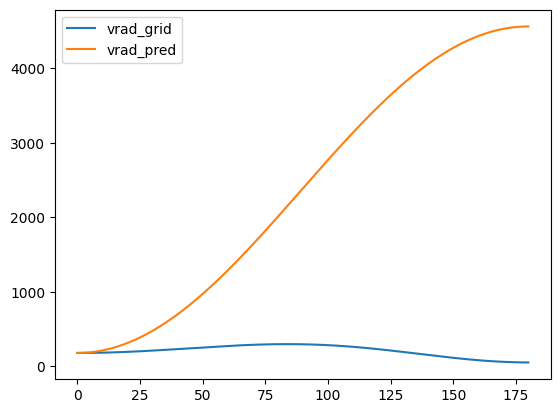

In [435]:
plt.figure()
plt.plot(phi_grid, vrad_from_grid, label="vrad_grid")

plt.plot(phi_grid, vrad_pred, label="vrad_pred")

plt.legend()


plt.show()

In [343]:
vx = vx.astype(np.float64)
vy = vy.astype(np.float64)
vrad = vrad.astype(np.float64)

In [380]:

rmax = 100
boxsize = 2 * rmax
ngrid = 8

r = np.linspace(0, rmax, ngrid)

x = boxsize / ngrid * (np.arange(ngrid) + 0.5) - boxsize / 2
X = np.vstack([x.reshape(-1,) for x in np.meshgrid(x, x, x)]).T




In [383]:
k = 3

x, y = csiborgtools.flow.void_velocity_vector(X, vx[k], vy[k], r_grid, phi_grid, vrad[k], vvoid_to_subtract=None)

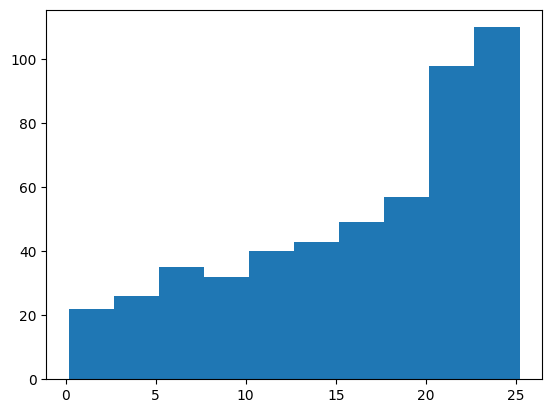

In [384]:
plt.figure()
plt.hist(x - y, bins="auto")
plt.show()

In [358]:
y

array([3099.23352428, 3036.02850615, 2970.38276863, ...,  -52.59709503,
        -77.04272639,  -97.74078516])

In [329]:
X = np.random.uniform(-rmax, rmax, (100000, 3))
r = np.linalg.norm(X, axis=1)
m = r < rmax

X = X[m]
r = r[m]

In [335]:
vel = csiborgtools.flow.void_velocity_vector(X, vx[30], vy[30], r_grid, phi_grid, vvoid_to_subtract=None)

In [336]:
np.linalg.norm(np.nanmean(vel, axis=0))

2235.152223148405

In [ ]:
2569.379

In [295]:
np.linalg.norm(np.nanmean(vel, axis=0))

94.80199470775501

In [281]:
vx_grid = vel[..., 0].reshape(ngrid, ngrid, ngrid)
enclosed_vx, enclosed_vol = field_enclosed_mass(vx_grid, r, boxsize)
enclosed_vx /= enclosed_vol

vy_grid = vel[..., 1].reshape(ngrid, ngrid, ngrid)
enclosed_vy, enclosed_vol = field_enclosed_mass(vy_grid, r, boxsize)
enclosed_vy /= enclosed_vol

vz_grid = vel[..., 2].reshape(ngrid, ngrid, ngrid)  
enclosed_vz, enclosed_vol = field_enclosed_mass(vz_grid, r, boxsize)
enclosed_vz /= enclosed_vol


100%|██████████| 32/32 [00:00<00:00, 10232.35it/s]
/tmp/ipykernel_1923223/209316873.py:3: RuntimeWarning: invalid value encountered in divide
  enclosed_vx /= enclosed_vol
100%|██████████| 32/32 [00:00<00:00, 10412.55it/s]
/tmp/ipykernel_1923223/209316873.py:7: RuntimeWarning: invalid value encountered in divide
  enclosed_vy /= enclosed_vol
100%|██████████| 32/32 [00:00<00:00, 10450.65it/s]
/tmp/ipykernel_1923223/209316873.py:11: RuntimeWarning: invalid value encountered in divide
  enclosed_vz /= enclosed_vol


In [282]:
bf_mag = np.sqrt(enclosed_vx**2 + enclosed_vy**2 + enclosed_vz**2)

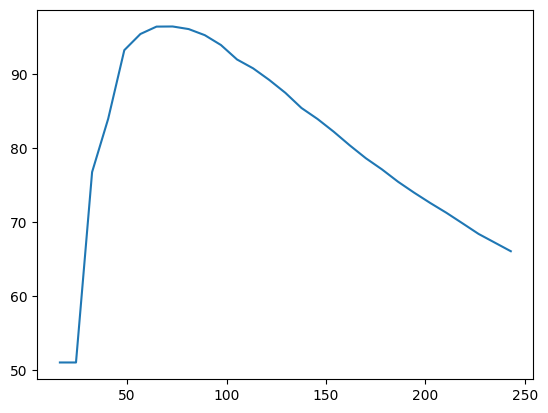

In [283]:
plt.figure()
plt.plot(r, bf_mag, label="vx")
plt.show()

(32768, 3)

In [189]:
# X = np.random.uniform(-250, 250, (100, 3))
gen = np.random.default_rng(42)
X = gen.uniform(-100, 100, (256**3, 3))

In [190]:
x = csiborgtools.flow.void_velocity_vector(X, vx[0], vy[0], r_grid, phi_grid)

In [193]:
x

array([[ -345.43985563,   -98.75719806, -1342.17863232],
       [ -541.71993391,  -762.53635335, -1173.20726354],
       [ -382.14335169,   626.23982921, -2871.37235283],
       ...,
       [-1827.159473  ,   108.60963876, -1687.97336472],
       [-1515.43536259,  -423.99405775, -2988.65958818],
       [ -350.30398656,   511.61435773, -1492.80146204]])

In [179]:
np.linalg.norm(np.asarray([0.4035093, -0.01363162, 0.91487399]))

0.9999999969144172

In [173]:
dv = x - y

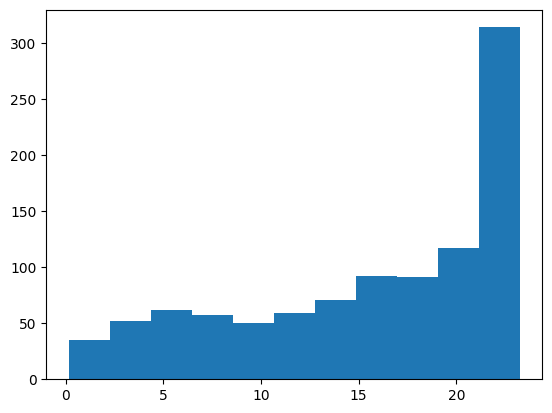

In [177]:
plt.figure()
plt.hist(x - y, bins="auto")
plt.show()

In [98]:
x

array([[ 6.70796955e-01,  3.67347461e-02, -2.95310680e-01],
       [-4.59447860e-01,  4.49392259e-01,  2.09337490e-01],
       [ 2.04511038e-01, -9.53165029e-01, -1.04402673e-01],
       [-7.56633493e-01, -3.69626858e-01,  3.28209173e-01],
       [-4.70035473e-01, -5.25652566e-01,  1.99479048e-01],
       [ 4.98131653e-01, -7.09611084e-01, -2.30276419e-01],
       [ 7.11552840e-01,  1.98191491e-01, -3.10880541e-01],
       [ 7.15060118e-01,  1.94436074e-01, -3.12483397e-01],
       [-2.99008385e-01,  4.84641211e-01,  1.39100155e-01],
       [-4.86700700e-01,  8.09311944e-01,  2.26720286e-01],
       [-8.50830153e-01,  3.49824766e-01,  3.80474864e-01],
       [-4.18897355e-01, -7.39826884e-01,  1.73733146e-01],
       [ 7.87342424e-01, -3.89402781e-01, -3.53063026e-01],
       [-3.78178158e-01, -1.87106585e-03,  1.66769310e-01],
       [ 8.22142986e-01,  7.72218372e-02, -3.61459270e-01],
       [-1.33127050e-01,  2.48853798e-01,  6.24242003e-02],
       [ 4.76124238e-01,  8.09331353e-01

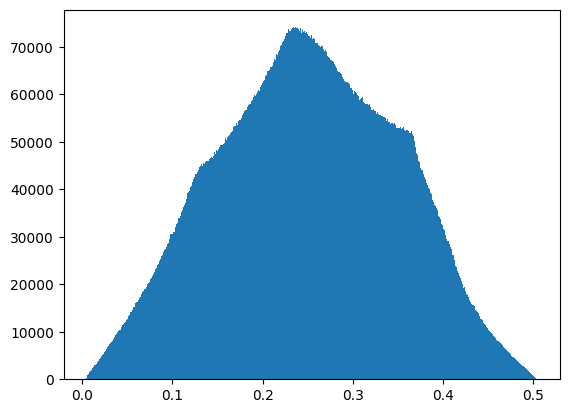

In [44]:
plt.figure()
plt.hist(np.arccos(cos_phi) / np.pi, bins="auto")
plt.show()

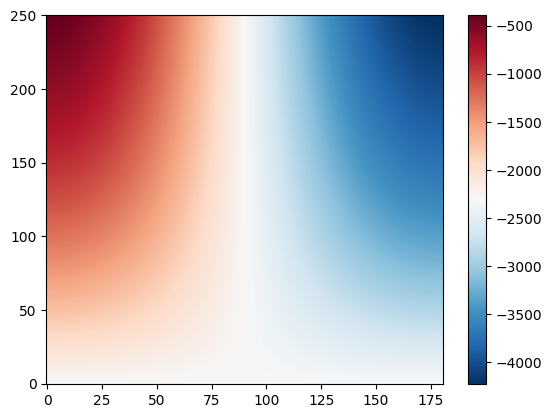

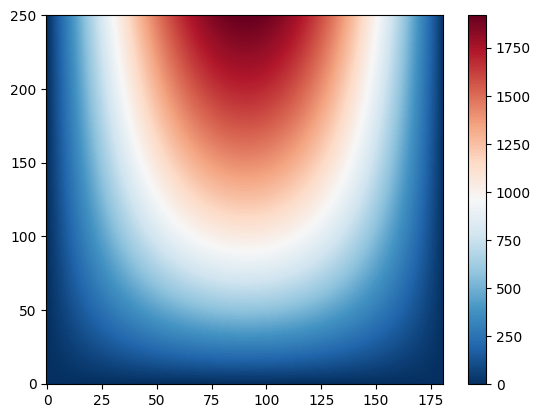

In [14]:
plt.figure()
plt.imshow(vx[0], origin="lower", cmap="RdBu_r", aspect="auto", )
plt.colorbar()

plt.show()

plt.figure()
plt.imshow(vy[0], origin="lower", cmap="RdBu_r", aspect="auto", )
plt.colorbar()

plt.show()